In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import pandas as pd

P3 = Path("../../images/p3")

def load_gray(path):
    arr = np.asarray(Image.open(path).convert("L"), dtype=np.uint8)
    return arr

def load_pair(inp_name, out_name):
    x = load_gray(P3 / inp_name)
    y = load_gray(P3 / out_name)
    assert x.shape == y.shape, f"Shape mismatch: {x.shape} vs {y.shape}"
    return x, y

def show_pair(x, y, title=""):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(x, cmap="gray", vmin=0, vmax=255)
    ax[0].set_title("Input")
    ax[1].imshow(y, cmap="gray", vmin=0, vmax=255)
    ax[1].set_title("True output")
    for a in ax:
        a.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## 3.1 — Recover the transfer curve

For a pointwise transform,

\[
I_{out}(p) = T[I_{in}(p)].
\]

Therefore, for every input intensity `v`, all output values at pixels where `img_in == v` should be samples of `T[v]`. Because the output is 8-bit, the conditional mean is a useful estimate of the underlying transform.

We also store the number of supporting pixels for every level. This distinction is essential: `cnt[v] == 0` means the image gives us **no information** about `T[v]`; it is different from a genuinely observed value whose transform happens to be zero.


In [ ]:
def transfer_curve(img_in, img_out):
    x = np.asarray(img_in)
    y = np.asarray(img_out)
    xf = x.ravel().astype(np.int16)
    yf = y.ravel().astype(np.float64)

    cnt = np.bincount(xf, minlength=256).astype(np.int64)
    sums = np.bincount(xf, weights=yf, minlength=256)

    T = np.full(256, np.nan, dtype=np.float64)
    observed = cnt > 0
    T[observed] = sums[observed] / cnt[observed]
    return T, cnt


def measured_scatter(T, cnt):
    v = np.arange(256)
    ok = cnt > 0
    return v[ok], T[ok], cnt[ok]


In [ ]:
# Recover A and B
field_in = load_gray("../../images/p3/field_in.png")
field_A = load_gray("../../images/p3/field_out_A.png")
field_B = load_gray("../../images/p3/field_out_B.png")

T_A, cnt_A = transfer_curve(field_in, field_A)
T_B, cnt_B = transfer_curve(field_in, field_B)


A: observed input levels: 256
B: observed input levels: 256
A: min/max observed level: [  0 255]
B: min/max observed level: [  0 255]


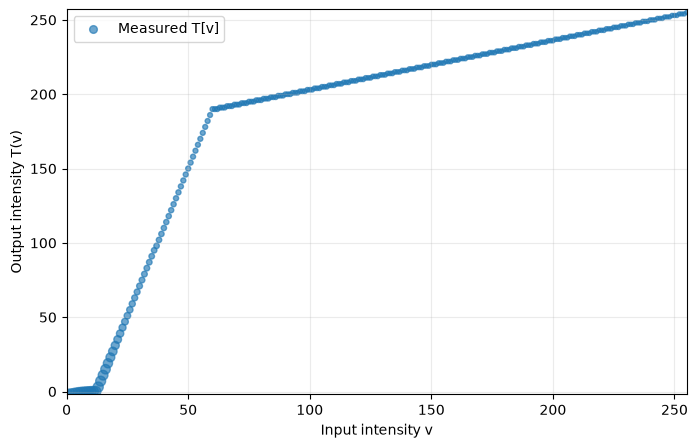

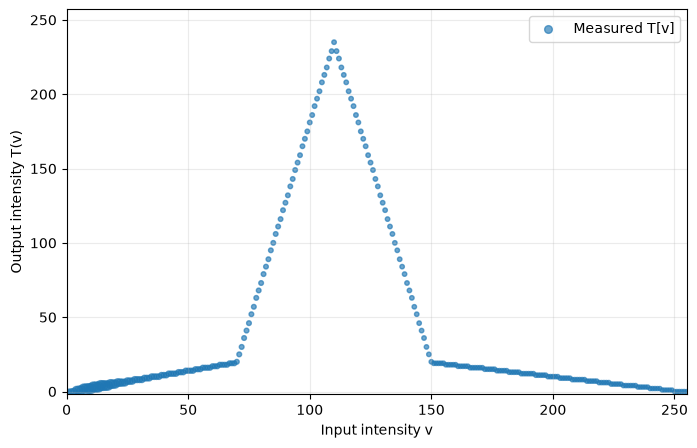

In [20]:
def plot_measured_curve(T, cnt, fitted=None):
    v = np.arange(256)
    ok = cnt > 0

    plt.figure(figsize=(8, 5))
    sizes = 8 + 45 * (cnt[ok] / cnt[ok].max())**0.5
    plt.scatter(v[ok], T[ok], s=sizes, alpha=0.65, label="Measured T[v]")

    if fitted is not None:
        lut, bps, slopes, inter = fitted
        plt.plot(v, lut, linewidth=2, label="Piecewise-linear fit")
        for b in bps:
            plt.axvline(b, linestyle="--", alpha=0.5)

    plt.xlim(0, 255)
    plt.ylim(-2, 257)
    plt.xlabel("Input intensity v")
    plt.ylabel("Output intensity T(v)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

plot_measured_curve(T_A, cnt_A)
plot_measured_curve(T_B, cnt_B)


In [ ]:
def _weighted_line_fit(x, y, w):
    """Weighted least-squares line y = m*x + c."""
    w = np.asarray(w, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    sw = w.sum()
    if sw <= 0:
        return 0.0, 0.0, np.inf

    sx = np.sum(w * x)
    sy = np.sum(w * y)
    sxx = np.sum(w * x * x)
    sxy = np.sum(w * x * y)

    denom = sw * sxx - sx * sx
    if abs(denom) < 1e-12:
        m = 0.0
        c = sy / sw
    else:
        m = (sw * sxy - sx * sy) / denom
        c = (sy - m * sx) / sw

    resid = y - (m * x + c)
    sse = np.sum(w * resid * resid)
    return float(m), float(c), float(sse)


def _segment_tables(T, cnt):
    levels = np.flatnonzero(cnt > 0)
    y = T[levels]
    w = cnt[levels].astype(np.float64)
    n = len(levels)

    slopes = np.zeros((n, n))
    intercepts = np.zeros((n, n))
    costs = np.full((n, n), np.inf)

    for i in range(n):
        for j in range(i, n):
            m, c, sse = _weighted_line_fit(levels[i:j+1], y[i:j+1], w[i:j+1])
            slopes[i, j] = m
            intercepts[i, j] = c
            costs[i, j] = sse

    return levels, slopes, intercepts, costs


def _dp_for_k(levels, costs, slopes, intercepts, k):
    n = len(levels)
    dp = np.full((k + 1, n), np.inf)
    prev = np.full((k + 1, n), -1, dtype=int)
    dp[1, :] = costs[0, :]

    for s in range(2, k + 1):
        for j in range(s - 1, n):
            # Last segment begins at q and ends at j.
            q_candidates = np.arange(s - 2, j)
            vals = dp[s - 1, q_candidates] + costs[q_candidates + 1, j]
            q_best = q_candidates[np.argmin(vals)]
            dp[s, j] = vals.min()
            prev[s, j] = q_best


    intervals = []
    j = n - 1
    for s in range(k, 0, -1):
        if s == 1:
            i = 0
        else:
            q = prev[s, j]
            i = q + 1
        intervals.append((i, j))
        if s > 1:
            j = prev[s, j]
    intervals.reverse()

    return dp[k, n - 1], intervals


def fit_piecewise(T, cnt, max_seg=6):
    T = np.asarray(T, dtype=np.float64)
    cnt = np.asarray(cnt)

    levels, slopes_tab, intercepts_tab, costs = _segment_tables(T, cnt)
    n = len(levels)

    if n == 0:
        raise ValueError("No observed input levels")
    max_seg = min(max_seg, n)

    total_weight = float(cnt.sum())
    candidates = []

    quant_floor = total_weight / 12.0

    for k in range(1, max_seg + 1):
        sse, intervals = _dp_for_k(levels, costs, slopes_tab, intercepts_tab, k)
        p = 2 * k
        sse_for_bic = max(sse, 1e-12)
        bic = total_weight * np.log(sse_for_bic / total_weight) + p * np.log(total_weight)

        candidates.append({"k": k,"sse": sse,"bic": bic,"intervals": intervals,})

    best = min(candidates, key=lambda d: d["bic"])
    for cand in candidates:
        if cand["k"] < best["k"]:
            improvement = cand["sse"] - best["sse"]
            if improvement < 2.0 * quant_floor:
                best = cand
                break

    intervals = best["intervals"]
    bps = []
    m_out = []
    c_out = []

    for i, j in intervals:
        bps.append(int(levels[j]))
        m_out.append(float(slopes_tab[i, j]))
        c_out.append(float(intercepts_tab[i, j]))

    return bps, m_out, c_out, int(best["k"])


def piecewise_lut(bps, slopes, inter):
    v = np.arange(256, dtype=np.float64)
    lut = np.empty(256, dtype=np.float64)

    left = 0
    for b, m, c in zip(bps, slopes, inter):
        right = int(np.clip(b, left, 255))
        lut[left:right+1] = m * v[left:right+1] + c
        left = right + 1

    if left < 256:
        m = slopes[-1]
        c = inter[-1]
        lut[left:] = m * v[left:] + c

    return np.clip(np.rint(lut), 0, 255).astype(np.uint8)


def apply_recovered(img, bps, slopes, inter):
    lut = piecewise_lut(bps, slopes, inter)
    return lut[np.asarray(img, dtype=np.uint8)]


def fit_report(T, cnt, bps, slopes, inter):
    rows = []
    start = 0
    for i, (b, m, c) in enumerate(zip(bps, slopes, inter), start=1):
        rows.append({
            "segment": i,
            "input range": f"{start}–{b}",
            "breakpoint": b,
            "slope": m,
            "intercept": c,
            "support pixels": int(cnt[start:b+1].sum()),
        })
        start = b + 1
    return pd.DataFrame(rows)


A:


,segment,input range,breakpoint,slope,intercept,support pixels
0,1,0–12,12,0.000000,0.000000,380639
1,2,13–60,60,3.977657,-48.624469,454088
2,3,61–255,255,0.333311,169.668825,37273



B:


,segment,input range,breakpoint,slope,intercept,support pixels
0,1,0–69,69,0.285512,-0.425889,839503
1,2,70–109,109,5.372934,-356.500530,12538
2,3,110–150,150,-5.374621,825.775328,8076
3,4,151–255,255,-0.190275,48.050859,11883


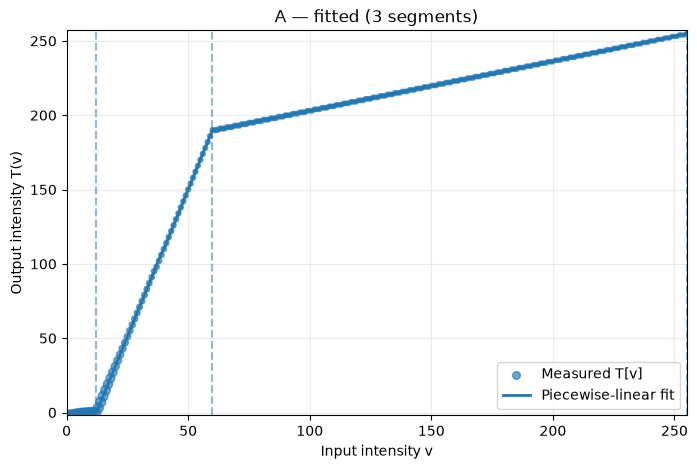

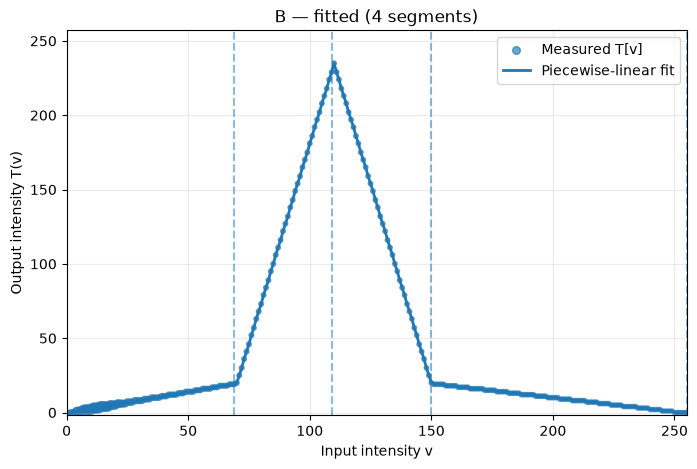

In [ ]:
bps_A, slopes_A, inter_A, n_A = fit_piecewise(T_A, cnt_A, max_seg=6)
bps_B, slopes_B, inter_B, n_B = fit_piecewise(T_B, cnt_B, max_seg=6)

lut_A = piecewise_lut(bps_A, slopes_A, inter_A)
lut_B = piecewise_lut(bps_B, slopes_B, inter_B)

print("A:")
display(fit_report(T_A, cnt_A, bps_A, slopes_A, inter_A))
print("\nB:")
display(fit_report(T_B, cnt_B, bps_B, slopes_B, inter_B))

plot_measured_curve(T_A, cnt_A, f"A — fitted ({n_A} segments)",
                    (lut_A, bps_A, slopes_A, inter_A))
plot_measured_curve(T_B, cnt_B, f"B — fitted ({n_B} segments)",
                    (lut_B, bps_B, slopes_B, inter_B))


A re-application: max |error| = 1, mean |error| = 0.005822
B re-application: max |error| = 0, mean |error| = 0.000000


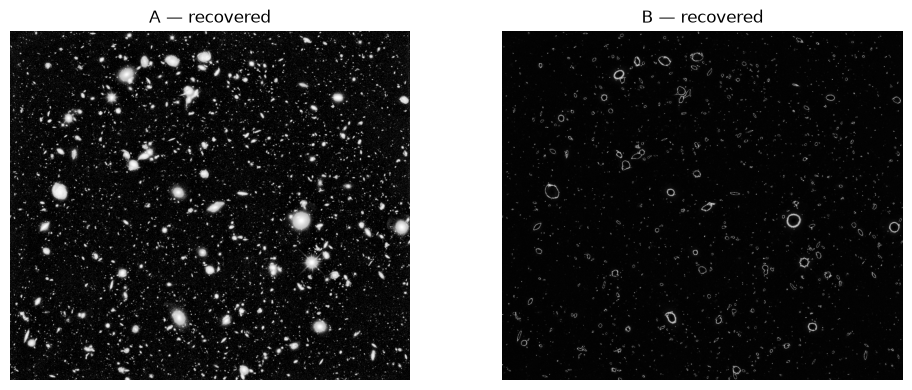

In [9]:
def error_against_true(pred, true):
    d = np.abs(pred.astype(np.int16) - true.astype(np.int16))
    return int(d.max()), float(d.mean())

A_recovered = apply_recovered(field_in, bps_A, slopes_A, inter_A)
B_recovered = apply_recovered(field_in, bps_B, slopes_B, inter_B)

max_A, mean_A = error_against_true(A_recovered, field_A)
max_B, mean_B = error_against_true(B_recovered, field_B)

print(f"A re-application: max |error| = {max_A}, mean |error| = {mean_A:.6f}")
print(f"B re-application: max |error| = {max_B}, mean |error| = {mean_B:.6f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(A_recovered, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("A — recovered")
ax[1].imshow(B_recovered, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("B — recovered")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()


- the break points for function A are 0-12, 13-60, 61-255
- the break points for function B are 0-69, 70-109, 110-150, 151-255

- the slope for function A in the 3 sections were:  0, 3.977, 0.331
- the slope for function B in the 4 sections were: 0.285, 5.372, -5.372, -0.190

- the maximum error on reapplication of A was 1 and the mean error was 0.005
- the maximum error on reapplication of B was 0 and the mean error was 0.000

- Recovery can be seen as a function from the input the the output. For an image to be recovered from the output alone there should be one input level asociated with one output level ie the mapping function should be a one-one and onto. In the mapping function of B we notice that the map has both positive and negative slope or in other words for different values of x there was same value of y (output level) hece making the function many to one and thus not invertible



,segments,weighted SSE,BIC
0,1,1.157460e+09,1.565181e+07
1,2,1.267336e+07,4.094766e+06
2,3,1.216076e+06,-1.905519e+06
3,4,2.022794e+05,-6.497450e+06
4,5,1.950106e+05,-6.591107e+06
5,6,1.892546e+05,-6.667777e+06


Selected number of segments: 4


,segment,input range,breakpoint,slope,intercept,support pixels
0,1,0–39,39,0.368258,4.748595,53253
1,2,40–120,120,2.249941,-70.368349,1875719
2,3,121–198,198,0.313324,161.901313,587292
3,4,199–255,255,0.543363,115.932571,43736


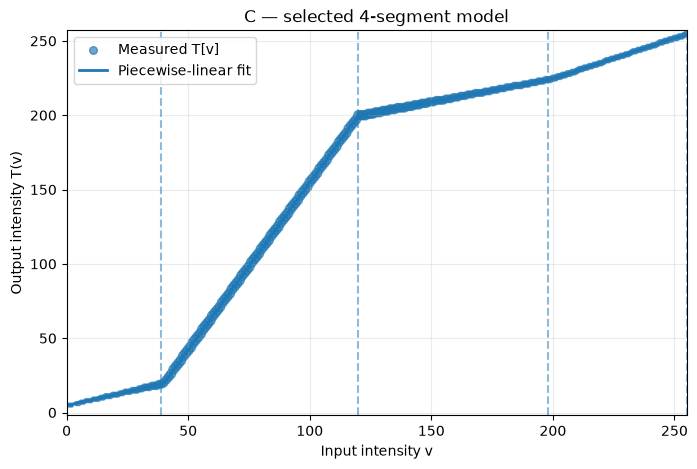

C re-application: max |error| = 1, mean |error| = 0.000139


In [11]:
nebula_in = load_gray("../../images/p3/nebula_in.png")
nebula_C = load_gray("../../images/p3/nebula_out_C.png")

T_C, cnt_C = transfer_curve(nebula_in, nebula_C)

levels_C, slopes_tab_C, intercepts_tab_C, costs_C = _segment_tables(T_C, cnt_C)
candidate_rows = []
total_weight_C = cnt_C.sum()

for k in range(1, min(6, len(levels_C)) + 1):
    sse, intervals = _dp_for_k(levels_C, costs_C, slopes_tab_C, intercepts_tab_C, k)
    p = 2 * k
    bic = total_weight_C * np.log(max(sse, 1e-12) / total_weight_C) + p * np.log(total_weight_C)
    candidate_rows.append({"segments": k, "weighted SSE": sse, "BIC": bic})

candidate_df = pd.DataFrame(candidate_rows)
display(candidate_df)

bps_C, slopes_C, inter_C, n_C = fit_piecewise(T_C, cnt_C, max_seg=6)
lut_C = piecewise_lut(bps_C, slopes_C, inter_C)
C_recovered = apply_recovered(nebula_in, bps_C, slopes_C, inter_C)

print(f"Selected number of segments: {n_C}")
display(fit_report(T_C, cnt_C, bps_C, slopes_C, inter_C))

plot_measured_curve(T_C, cnt_C, f"C — selected {n_C}-segment model",
                    (lut_C, bps_C, slopes_C, inter_C))

max_C, mean_C = error_against_true(C_recovered, nebula_C)
print(f"C re-application: max |error| = {max_C}, mean |error| = {mean_C:.6f}")


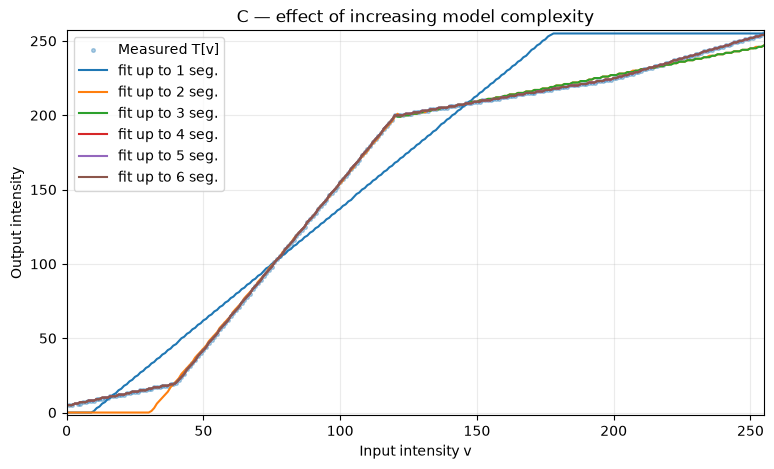

In [12]:
v = np.arange(256)
ok = cnt_C > 0

plt.figure(figsize=(9, 5))
plt.scatter(v[ok], T_C[ok], s=7, alpha=0.35, label="Measured T[v]")

for k in range(1, min(6, len(levels_C)) + 1):
    b, m, c, _ = fit_piecewise(T_C, cnt_C, max_seg=k)
    lut = piecewise_lut(b, m, c)
    plt.plot(v, lut, linewidth=1.5, label=f"fit up to {k} seg.")

plt.xlabel("Input intensity v")
plt.ylabel("Output intensity")
plt.title("C — effect of increasing model complexity")
plt.xlim(0, 255)
plt.ylim(-2, 257)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


1. Number of selected segments = 4
2. checking if current_sse - best_sse < 2.0 * quant_floor => Here quant floor is chosen considering the error to be a uniform random variable in [-0.5, 0.5] whose variance is 1/12.
3. The true transformation is piecewise linear, but the output image is only 8bit so the true continuous line gets rounded into integer output values. So a straightline is quantised to several tiny deviations due to this quantization. If we use 1 segment to capture this straight line we will capture this line function reasonably well but if we keep increasing the number of segments we will start fitting on the deviations caused by quantisation instead. 
4. The weighted BIC and SSE table shows that the SSE decreases as the number of segments increase. The BIC however considers the model complexity as well - it decreases initially as adding segments improves the SSE by a lot, but after 4 (which is the desired fit) it increases as the complexity overweighs the benefit of adding the segment. 


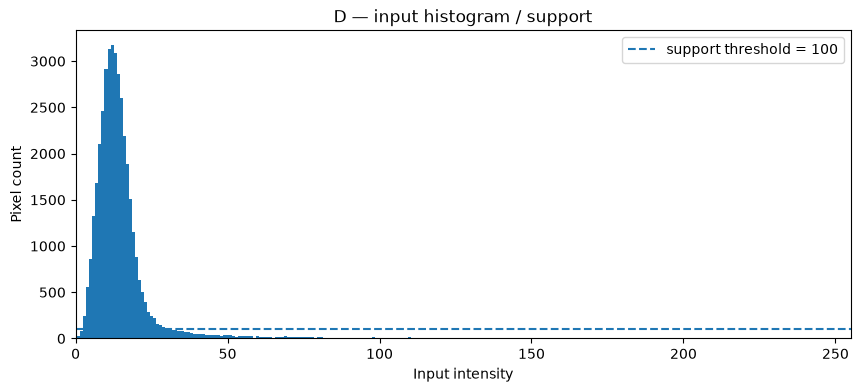

Observed levels: [  0 246]
Number of observed levels: 239
Number of well-supported levels: 29


In [ ]:
field_D_in = load_gray("../../images/p3/field_skycrop_in.png")
field_D = load_gray("../../images/p3/field_skycrop_out_D.png")

T_D, cnt_D = transfer_curve(field_D_in, field_D)

SUPPORT_THRESHOLD = 100

v = np.arange(256)

plt.figure(figsize=(10, 4))
plt.bar(v, cnt_D, width=1.0)
plt.axhline(SUPPORT_THRESHOLD, linestyle="--",
            label=f"support threshold = {SUPPORT_THRESHOLD}")
plt.xlabel("Input intensity")
plt.ylabel("Pixel count")
plt.title("D — input histogram / support")
plt.xlim(0, 255)
plt.legend()
plt.show()

sampled = cnt_D > 0
supported = cnt_D >= SUPPORT_THRESHOLD

print("Observed levels:", np.where(sampled)[0][[0, -1]] if sampled.any() else "none")
print("Number of observed levels:", sampled.sum())
print("Number of well-supported levels:", supported.sum())


In [15]:
def contiguous_ranges(mask):
    """Return inclusive contiguous ranges where mask is True."""
    mask = np.asarray(mask, dtype=bool)
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return []

    ranges = []
    start = prev = int(idx[0])

    for q in idx[1:]:
        q = int(q)
        if q == prev + 1:
            prev = q
        else:
            ranges.append((start, prev))
            start = prev = q

    ranges.append((start, prev))
    return ranges


def support_report(cnt, **kw):
    """Return a human-readable support report.

    Parameters accepted through **kw:
      threshold: minimum number of pixels required for trust
    """
    threshold = int(kw.get("threshold", 100))
    cnt = np.asarray(cnt)

    observed = cnt > 0
    supported = cnt >= threshold

    weak_or_missing = ~supported

    lines = [
        f"Support threshold: {threshold} pixels/level",
        f"Observed levels: {int(observed.sum())}/256",
        f"Well-supported levels: {int(supported.sum())}/256",
        f"Observed but weakly supported levels: {int(np.sum(observed & ~supported))}",
        f"Completely unobserved levels: {int(np.sum(~observed))}",
        f"Well-supported ranges: {contiguous_ranges(supported)}",
        f"Unconstrained/weak ranges: {contiguous_ranges(weak_or_missing)}",
    ]
    return "\n".join(lines)


print(support_report(cnt_D, threshold=SUPPORT_THRESHOLD))


Support threshold: 100 pixels/level
Observed levels: 239/256
Well-supported levels: 29/256
Observed but weakly supported levels: 210
Completely unobserved levels: 17
Well-supported ranges: [(3, 31)]
Unconstrained/weak ranges: [(0, 2), (32, 255)]


Supported ranges:
[(3, 31)]
Segments reported from supported data: 2


,segment,input range,breakpoint,slope,intercept,support pixels
0,1,0–20,20,1.501208,-0.261779,34630
1,2,21–31,31,4.899915,-68.747187,2928


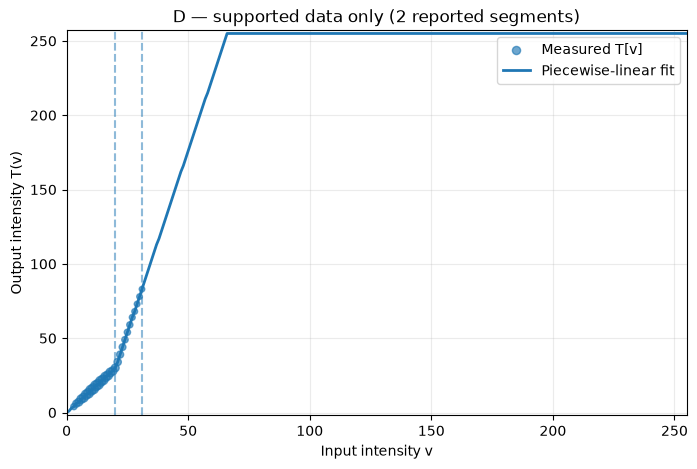

Overall max |error|: 52
Overall mean |error|: 0.9334
Mean |error| on supported pixels: 0.0


In [18]:
# Fit the transform using only sufficiently supported levels.
T_D_supported = T_D.copy()
cnt_D_supported = cnt_D.copy()

cnt_D_supported[cnt_D_supported < SUPPORT_THRESHOLD] = 0
T_D_supported[cnt_D_supported == 0] = np.nan

print("Supported ranges:")
print(contiguous_ranges(cnt_D_supported > 0))


bps_D, slopes_D, inter_D, n_D = fit_piecewise(T_D_supported, cnt_D_supported, max_seg=6)

lut_D = piecewise_lut(bps_D, slopes_D, inter_D)

print(f"Segments reported from supported data: {n_D}")
display(fit_report(T_D_supported, cnt_D_supported, bps_D, slopes_D, inter_D))

plot_measured_curve(
    T_D_supported, cnt_D_supported,
    f"D — supported data only ({n_D} reported segments)",
    (lut_D, bps_D, slopes_D, inter_D)
)

D_recovered = apply_recovered(field_D_in, bps_D, slopes_D, inter_D)

# Error is shown for reference, but interpretation must be restricted to
# the supported input levels because unsupported levels are unidentifiable.
diff_D = np.abs(D_recovered.astype(np.int16) - field_D.astype(np.int16))
support_mask_pixels = cnt_D[field_D_in] >= SUPPORT_THRESHOLD

print("Overall max |error|:", int(diff_D.max()))
print("Overall mean |error|:", float(diff_D.mean()))
print("Mean |error| on supported pixels:",
      float(diff_D[support_mask_pixels].mean()) if support_mask_pixels.any() else np.nan)


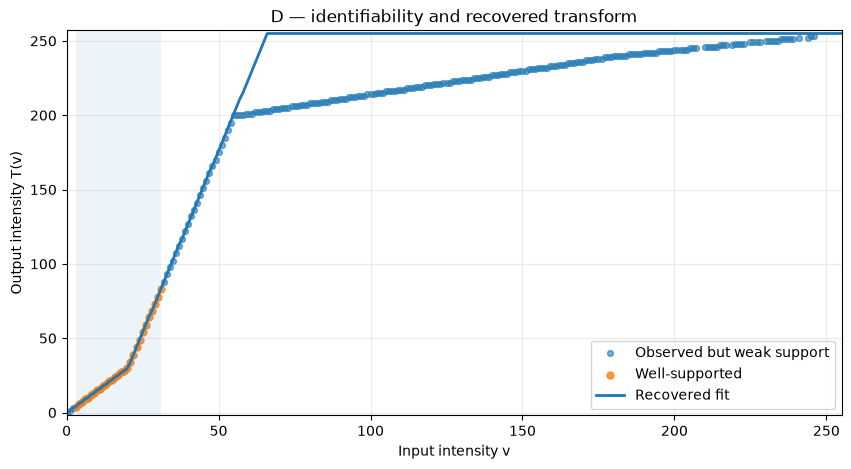

In [17]:
# Show where the D answer is constrained vs. unsupported.
v = np.arange(256)
plt.figure(figsize=(10, 5))
ok = cnt_D > 0
weak = (cnt_D > 0) & (cnt_D < SUPPORT_THRESHOLD)
good = cnt_D >= SUPPORT_THRESHOLD

plt.scatter(v[weak], T_D[weak], s=18, alpha=0.6, label="Observed but weak support")
plt.scatter(v[good], T_D[good], s=25, alpha=0.8, label="Well-supported")
plt.plot(v, lut_D, linewidth=2, label="Recovered fit")

for a, b in contiguous_ranges(good):
    plt.axvspan(a, b, alpha=0.08)

plt.xlabel("Input intensity v")
plt.ylabel("Output intensity T(v)")
plt.title("D — identifiability and recovered transform")
plt.xlim(0, 255)
plt.ylim(-2, 257)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


- I chose the supported threshold as 100 as around the peak the frequency is in 1000s as the intensity goes past 30 there is sharp decrease with less than 100 pixels around the 35-40 mark Beyond 50 there are very few pixels relatively and hence threshold wont be reliable. 
- Using a support threshold of 100 pixels per input intensity level, 239 of the 256 intensity levels are observed, but only 29 levels are sufficiently supported. These are from the range 3-31 so the recovered transform is only considered reliable over the range 3–31.
- segments from 0-20 and 21-31 can be determined
- In the range 3-31 there are 2 major segments from 3-20 where the curve rises slowly and 21-31 with a much steeper slope. As all other other 2 changes (causing the 4 segmenets) happen outside the supported range these cant be determined 